# 바나프레소 입지 추천 분석
+ rule-based로 점수화하여 추천할 계획
+ 왜냐하면, 데이터가 부족함.
    - 영업 중인 바나프레소 59개(이 중 3년 이상은 10개), 폐업된 바나프레소 4개 <br>
        ∴ 어떤 모델도 돌리기에는 설명력이 너무 부족

In [2]:
import numpy as np
import pandas as pd
import re
import geopandas as gpd
from haversine import haversine, Unit
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

In [3]:
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트

# 1. 바나프레소 정보만 가져오기

1. 서울 카페 정보 중 **바나프레소** 인 것만 필터링.
2. 3년 이상 영업 가게를 성공(생존) 가게로 판단. ∴ apv_date 기준으로 3년 이상 된 가게를 success = 1 로 둠.

In [4]:
# 카페 데이터 가져오기
cafe = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/cafe.csv")
cafe.head()

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd
0,베레베레,커피숍,2002-09-19,서울 광진구 능동로13길 19,NaN,NaN,37.542885,127.070832,T,3120053.0,11215710
1,덕수궁전통차전문,커피숍,2003-01-16,서울 중구 서소문로 109,2.0,46.28,37.563062,126.973280,T,3120020.0,11140520
2,엘빠소,커피숍,2003-05-31,서울 종로구 성균관로 18,NaN,NaN,37.584406,126.997641,T,3110021.0,11110650
3,씨애틀즈베스트커피대사관점,커피숍,2003-10-31,서울 종로구 세종대로 188,1.0,NaN,37.573190,126.977831,A,NaN,11110615
4,본솔카페,커피숍,2004-01-17,서울 용산구 청파로47길 71,1.0,13.80,37.544840,126.966455,T,3110069.0,11170555


In [5]:
# 바나프레소만 추출
bana_df = cafe[cafe['nm'].str.contains(r"바나프레소|banapresso", case=False, na=False)].copy()
print(len(bana_df))

# 날짜 변환
bana_df['apv_date'] = pd.to_datetime(bana_df['apv_date'], errors='coerce')

# 오늘 기준 3년 이상(= 3년 전 이하) 된 매장만
cutoff = pd.Timestamp.today().normalize() - pd.DateOffset(years=3)
bana_df["success"] = (bana_df["apv_date"] <= cutoff).astype(int)

# 확인
bana_df["success"].value_counts()

59


success
0    49
1    10
Name: count, dtype: int64

# 2. 수요 점수 변수
최근 1년 즉, 2024년 4분기부터 2025년 3분기 까지의 데이터 사용 
<br>
- 2-1. 유동 인구_점심: tmzon_11_14_flpop_co
- 2-2. 유동 인구_저녁: tmzon_17_21_flpop_co
- 2-3. 유동 인구_기타 시간 평균: tmzon_00_06_flpop_co, tmzon_06_11_flpop_co, tmzon_14_17_flpop_co, tmzon_21_24_flpop_co

In [6]:
print(bana_df["flpop_type"].unique())

<StringArray>
['T', 'A']
Length: 2, dtype: str


In [7]:
# 유동인구 데이터 불러오기
flpop_t = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/flpop_t.csv")
flpop_a = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/flpop_a.csv")
print(flpop_t.columns)
print(flpop_a.columns)

Index(['stdr_yyqu_cd', 'trdar_se_cd_nm', 'trdar_cd', 'trdar_cd_nm',
       'tot_flpop_co', 'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co',
       'agrde_20_flpop_co', 'agrde_30_flpop_co', 'agrde_40_flpop_co',
       'agrde_50_flpop_co', 'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co',
       'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co',
       'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co',
       'tues_flpop_co', 'wed_flpop_co', 'thur_flpop_co', 'fri_flpop_co',
       'sat_flpop_co', 'sun_flpop_co'],
      dtype='str')
Index(['stdr_yyqu_cd', 'adstrd_cd', 'adstrd_cd_nm', 'tot_flpop_co',
       'ml_flpop_co', 'fml_flpop_co', 'agrde_10_flpop_co', 'agrde_20_flpop_co',
       'agrde_30_flpop_co', 'agrde_40_flpop_co', 'agrde_50_flpop_co',
       'agrde_60_above_flpop_co', 'tmzon_00_06_flpop_co',
       'tmzon_06_11_flpop_co', 'tmzon_11_14_flpop_co', 'tmzon_14_17_flpop_co',
       'tmzon_17_21_flpop_co', 'tmzon_21_24_flpop_co', 'mon_flpop_co',


In [8]:
# 최근 4개 분기 추출
recent_quarters = sorted(flpop_t["stdr_yyqu_cd"].unique())[-4:]

# 필터링
flpop_t = flpop_t[flpop_t["stdr_yyqu_cd"].isin(recent_quarters)]
flpop_a = flpop_a[flpop_a["stdr_yyqu_cd"].isin(recent_quarters)]

In [9]:
# 중복(이상치) 확인
print(flpop_t[["stdr_yyqu_cd","trdar_cd"]].duplicated().sum())
print(flpop_a[["stdr_yyqu_cd","adstrd_cd"]].duplicated().sum())

0
0


In [10]:
# 분기 평균 집계
agg_cols = ["tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co",
            "tmzon_00_06_flpop_co", "tmzon_06_11_flpop_co",
            "tmzon_14_17_flpop_co", "tmzon_21_24_flpop_co"]

flpop_t_agg = flpop_t.groupby("trdar_cd")[agg_cols].mean().reset_index()
flpop_a_agg = flpop_a.groupby("adstrd_cd")[agg_cols].mean().reset_index()

# etc 평균 계산
etc_cols = ["tmzon_00_06_flpop_co", "tmzon_06_11_flpop_co", "tmzon_14_17_flpop_co", "tmzon_21_24_flpop_co"]
flpop_t_agg["flpop_etc"] = flpop_t_agg[etc_cols].mean(axis=1)
flpop_a_agg["flpop_etc"] = flpop_a_agg[etc_cols].mean(axis=1)

In [53]:
flpop_a_agg

,adstrd_cd,tmzon_11_14_flpop_co,tmzon_17_21_flpop_co,tmzon_00_06_flpop_co,tmzon_06_11_flpop_co,tmzon_14_17_flpop_co,tmzon_21_24_flpop_co,flpop_etc
0,11110515,500612.50,578186.75,764008.75,695880.25,496522.75,396395.75,5.882019e+05
1,11110530,785096.00,800972.75,462503.75,833639.75,795807.75,329475.00,6.053566e+05
2,11110540,189512.25,162304.25,158158.75,197656.50,187852.75,80772.75,1.561102e+05
3,11110550,113146.00,138369.00,233406.50,193447.25,109598.75,114718.50,1.627928e+05
4,11110560,95763.00,138732.75,263526.50,190671.50,94246.75,123374.00,1.679547e+05
...,...,...,...,...,...,...,...,...
420,11740650,920444.50,1377540.25,2302846.00,1689404.25,935937.50,1107762.25,1.508988e+06
421,11740660,762420.50,1072372.75,1852932.25,1368657.50,746946.00,885058.75,1.213399e+06
422,11740685,2099678.75,2972146.50,4900869.50,3691237.75,2090460.00,2401415.00,3.270996e+06
423,11740690,2754.75,3662.25,6182.75,4974.50,2686.75,2983.00,4.206750e+03


In [11]:
# flpop_type T 매핑
tr_mask = bana_df["flpop_type"] == "T"
tr_merged = bana_df[tr_mask].merge(
    flpop_t_agg[["trdar_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="trdar_cd", how="left"
)

# flpop_type A 매핑
ad_mask = bana_df["flpop_type"] == "A"
ad_merged = bana_df[ad_mask].merge(
    flpop_a_agg[["adstrd_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="adstrd_cd", how="left"
)

# 합치기 & 컬럼명 정리
bana_df = pd.concat([tr_merged, ad_merged]).sort_index().rename(columns={
    "tmzon_11_14_flpop_co": "flpop_lunch",
    "tmzon_17_21_flpop_co": "flpop_dinner"
})

print(bana_df.shape)
bana_df.head()

(59, 15)


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,success,flpop_lunch,flpop_dinner,flpop_etc
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,11680650,1,985131.50,882135.00,752222.8125
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,11350621,0,418872.50,654206.75,676400.0625
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,11710647,0,353384.75,554050.25,582902.9375
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,11650531,1,589152.00,788268.00,560948.1250
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,11680590,1,951358.25,983513.00,833761.1250


In [55]:
len(bana_df)

59

    2-4. 학교 수
    2-5. 지식산업센터 수
    2-6. 병원 수 
    2-7. 학원 수
    2-8. 체육도장업 수 

In [13]:
academy = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/academy_df.csv")
gym = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/gym_df.csv")
hospital = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/hospital_df.csv")
physical = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/physical_df.csv")
school = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/school.csv")
center = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/industry_center.csv")
print(academy.columns)
print(gym.columns)
print(hospital.columns)
print(physical.columns)
print(school.columns)
print(center.columns)

Index(['idx', 'nm', 'addr', 'lat', 'lng'], dtype='str')
Index(['idx', 'dtlstatenm', 'addr', 'nm', 'type', 'lat', 'lng'], dtype='str')
Index(['idx', 'dtlstatenm', 'nm', 'type', 'addr', 'lat', 'lng'], dtype='str')
Index(['idx', 'dtlstatenm', 'addr', 'type', 'nm', 'lat', 'lng'], dtype='str')
Index(['idx', 'nm', 'addr', 'type', 'lat', 'lng'], dtype='str')
Index(['nm', 'type', 'addr', 'lat', 'lng'], dtype='str')


In [14]:
# academy 에 type 칼럼이 없어서 추가
academy['type'] = '학원'
academy.head()

,idx,nm,addr,lat,lng,type
0,1,클릭전원미술학원,서울특별시 마포구 와우산로 138 (창전동),37.553572,126.928993,학원
1,2,고려직업전문학교,서울특별시 동작구 노량진로 186 (노량진동),37.512575,126.946031,학원
2,3,노량진행정고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198,학원
3,4,박문각임용고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198,학원
4,5,노량진메가스터디입시어학원,서울특별시 동작구 장승배기로 171 (노량진동),37.513017,126.939945,학원


In [15]:
# 하나의 데이터프레임으로 만들기
dfs = [academy, gym, hospital, physical, school, center]

need_cols = ["type", "nm", "addr", "lat", "lng"]

# 각 df에서 필요한 컬럼만 추출(없는 컬럼은 NaN으로 생성)
picked = [d.reindex(columns=need_cols) for d in dfs]

# 세로로 합치기
buildings_df = pd.concat(picked, ignore_index=True)

buildings_df.head()

,type,nm,addr,lat,lng
0,학원,클릭전원미술학원,서울특별시 마포구 와우산로 138 (창전동),37.553572,126.928993
1,학원,고려직업전문학교,서울특별시 동작구 노량진로 186 (노량진동),37.512575,126.946031
2,학원,노량진행정고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198
3,학원,박문각임용고시학원,서울특별시 동작구 노량진로 171 (노량진동),37.514034,126.945198
4,학원,노량진메가스터디입시어학원,서울특별시 동작구 장승배기로 171 (노량진동),37.513017,126.939945


In [59]:
buildings_df['type'].unique()

<StringArray>
['학원', '병원', '학교', '지식산업센터']
Length: 4, dtype: str

In [16]:
# 반경 300m 안 개수 찾기

# 0) type 매핑
type_map = {
    "학원": "cnt_academy",
    "병원": "cnt_hospital",
    "학교": "cnt_school",
    "지식산업센터": "cnt_company"
}

# 1) 함수 정의
def count_buildings_nearby(cafe_lat, cafe_lon, buildings_df, radius=300):
    mask = buildings_df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    nearby = buildings_df[mask]
    counts = nearby.groupby("type").size()
    
    # 없는 type도 0으로 채우기
    counts = counts.reindex(type_map.keys(), fill_value=0)
    
    # 영어로 rename
    counts.index = [type_map[t] for t in counts.index]
    return counts

# 적용
result = bana_df.apply(
    lambda row: count_buildings_nearby(row["lat"], row["lng"], buildings_df),
    axis=1
).fillna(0).astype(int)

bana_df = pd.concat([bana_df, result], axis=1)
bana_df.head()

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,success,flpop_lunch,flpop_dinner,flpop_etc,cnt_academy,cnt_hospital,cnt_school,cnt_company
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,11680650,1,985131.50,882135.00,752222.8125,0,1,0,0
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,11350621,0,418872.50,654206.75,676400.0625,0,0,0,0
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,11710647,0,353384.75,554050.25,582902.9375,0,0,0,0
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,11650531,1,589152.00,788268.00,560948.1250,0,1,0,0
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,11680590,1,951358.25,983513.00,833761.1250,1,2,0,0


# 3. 접근성 점수 변수
    3-1. 지하철역 최소 거리
    3-2. 버스정류장 최소 거리
    3-3. 대로변 여부
    3-4. 횡단보도 수
    3-5. 층수

In [17]:
bus_stop = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/bus_stop.csv")
station = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/station.csv")
crosswalk = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/crosswalk.csv")
road = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/road.csv")

print(bus_stop.columns)
print(station.columns)
print(crosswalk.columns)
print(road.columns)

Index(['bus_stop_id', 'bus_stop_nm', 'lng', 'lat', 'type'], dtype='str')
Index(['addr', 'type', 'lat', 'lng'], dtype='str')
Index(['lng', 'lat', 'sigungu', 'emd', 'type'], dtype='str')
Index(['road_address', 'lng', 'lat', 'type'], dtype='str')


In [41]:
# 최소 거리
def min_distance(cafe_lat, cafe_lon, df):
    distances = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ), axis=1
    )
    return distances.min()

# 300m 안 횡단보도 개수
def count_within(cafe_lat, cafe_lon, df, radius=300):
    mask = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    return mask.sum()

# 300m 안 대로변 여부
def is_roadside(cafe_lat, cafe_lon, df, radius=300):
    mask = df.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    return int(mask.any())  # 1개라도 있으면 1, 없으면 0

# bana_df에 적용
bana_df["dist_station"]    = bana_df.apply(lambda row: min_distance(row["lat"], row["lng"], station), axis=1)
bana_df["dist_bus_stop"]   = bana_df.apply(lambda row: min_distance(row["lat"], row["lng"], bus_stop), axis=1)
bana_df["cnt_crosswalk"] = bana_df.apply(lambda row: count_within(row["lat"], row["lng"], crosswalk), axis=1)
bana_df["is_road"]     = bana_df.apply(lambda row: is_roadside(row["lat"], row["lng"], road), axis=1)
bana_df.head(5)

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,dist_station,dist_bus_stop,cnt_crosswalk,is_road,profile_weight,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe,floor_score
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.40,37.501130,127.039099,T,3120197.0,...,223.598018,24.766102,8,1,3.0,0,6,6,27,1.0
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.70,37.654291,127.075304,A,NaN,...,750.922345,116.274918,18,1,1.0,0,0,1,1,1.0
1,banapresso 위례중앙점,커피숍,2023-05-01,서울 송파구 위례광장로 120,1.0,40.10,37.475010,127.141593,A,NaN,...,1379.887436,72.955206,23,1,1.0,0,0,1,4,1.0
1,바나프레소 신논현역점,커피숍,2019-08-06,서울 서초구 사평대로 364,1.0,107.24,37.503733,127.023196,T,3120187.0,...,765.979395,57.031538,18,1,3.0,0,6,7,36,1.0
2,바나프레소 선릉공원점,커피숍,2021-07-23,서울 강남구 테헤란로63길 20,1.0,97.28,37.506522,127.050398,T,3120210.0,...,258.610257,139.653177,16,1,3.0,0,1,10,23,1.0


In [42]:
print(bana_df["dist_station"].isna().sum())

0


In [30]:
print(bana_df["floor"].isna().sum())
print(bana_df["floor"].value_counts().sort_index())

0
floor
-1.0     5
 1.0    54
Name: count, dtype: int64


In [31]:
# 1층 만점, 멀어질수록 감점
# 지하도 고려 (지하 = 음수)
def floor_score(floor):
    if floor == 1:
        return 1.0
    else:
        return max(1 - abs(floor - 1) * 0.2, 0) # 층수마다 0.2점씩 감점

bana_df["floor_score"] = bana_df["floor"].apply(floor_score)

# 4. 경쟁사 비교 점수 변수

In [65]:
cafe_nm = cafe['nm']
cafe_nm = cafe_nm.to_list()
cafe_nm

['베레베레',
 '덕수궁전통차전문',
 '엘빠소',
 '씨애틀즈베스트커피대사관점',
 '본솔카페',
 '링고요고',
 '토넷트커피숍',
 '썬휴게실',
 '네스카페',
 '루비콘플러스',
 '구스토',
 '아름다운고궁',
 '피카디리망고 일리',
 '소그노스에스프레소',
 '노모토커피',
 '주)키커피코리아',
 '강남커피숍',
 '캔모아',
 '북카페내서재',
 '플로리안',
 'BABIANA(바비아나)',
 '숭실대생협 아름다운세상',
 '보보스',
 '에스프레소인뉴욕',
 '할리스커피(Hollys Coffee)',
 '제일상회',
 '국립고궁박물관 뮤지엄숍',
 '모드뜨레',
 '카페돌로미티',
 '카페하임',
 '미래월드',
 '커피501(coffee501)',
 '메리메이트(MerryMate)',
 '귀천',
 '탐앤탐스노원점',
 '커피투어(Coffee Tour)',
 '쿠벅양평점',
 '세리커피(Coffee)',
 '테라 스위트(Terra sweet)본점',
 '물커피(Mool Coffee)',
 '세븐일레븐(서울시립대점)',
 '#11(Sharp eleven)',
 '커피보노',
 'ATM(에이티엠)',
 '미르엠(MIRM)',
 '토프레소 태평로점',
 'POLE243',
 'Meister haus',
 '빈스빈스',
 '이디야커피',
 '소풍',
 '다동커피집',
 '파나마',
 '동네커피',
 '영화에 빠진 커피',
 '두루',
 '니들 북',
 '헤이리커피공장103이촌점',
 '퓨얼리데카던트',
 '이디야올림픽공원점',
 '카페베네 종로5가점',
 '이디야 서대문점',
 '남산커피집',
 '보티',
 '커피데이',
 '아산엠 매점',
 '까사안띠구아',
 '커피홀릭',
 '카페깔리아리',
 '파반커피',
 '카페나루',
 '카페라비',
 '투미',
 '호텔디아망',
 '빈스커피',
 '투썸플레이스',
 '야노아',
 'An.s coffee',
 '슐레스',
 '알엔비스커피(RNBS COFFEE)',
 '아임빈',
 '바오밥나무 여성미래센

- 카페 분류는 AI의 도움을 받음
    1. 고가 프랜차이즈, 저가 프랜차이즈 기준과 예시를 입력.
    2. 위 내용(전체 카페 이름)을 입력.
    3. 1번 내용에 따라 브랜드 키워드 추출 (아래 코드 내용)

In [24]:
# 1) 이름 정규화 함수
def norm(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"[\s\.\,\-\(\)\[\]\/_]", "", s)  # 공백/기호 제거
    return s

# 2) 브랜드 키워드(필요시 추가/수정)
LOW_PATTERNS = [
    "메가엠지씨", "메가mgc", "메가커피",
    "빽다방",
    "컴포즈", "compose",
    "더벤티", "theventi",
    "매머드", "mammoth",
    "텐퍼센트", "tenpercent",
    "커피베이",
    "우지커피", "oozy",
    "백억커피",
    "벤티프레소", "ventipresso",
]

HIGH_PATTERNS = [
    "스타벅스", "starbucks",
    "투썸", "twosome",
    "폴바셋", "paulbassett",
    "커피빈", "coffeebean",
    "할리스", "hollys",
    "아티제", "artisee",
    "테라로사", "terarosa",
    "오설록", "osulloc",
]

BANA_PATTERNS = ["바나프레소", "banapresso"]

def contains_any(text, patterns):
    return any(p in text for p in patterns)

# 3) 분류 함수
def cafe_tier(name):
    x = norm(name)
    if contains_any(x, BANA_PATTERNS):
        return "banapresso"
    if contains_any(x, HIGH_PATTERNS):
        return "high"
    if contains_any(x, LOW_PATTERNS):
        return "low"
    return "etc"

# 4) 적용
cafe["detail"] = cafe["nm"].apply(cafe_tier)

# 확인
print(cafe["detail"].value_counts())
cafe.head()

detail
etc           11194
low            2209
high           1071
banapresso       59
Name: count, dtype: int64


,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,adstrd_cd,detail
0,베레베레,커피숍,2002-09-19,서울 광진구 능동로13길 19,NaN,NaN,37.542885,127.070832,T,3120053.0,11215710,etc
1,덕수궁전통차전문,커피숍,2003-01-16,서울 중구 서소문로 109,2.0,46.28,37.563062,126.973280,T,3120020.0,11140520,etc
2,엘빠소,커피숍,2003-05-31,서울 종로구 성균관로 18,NaN,NaN,37.584406,126.997641,T,3110021.0,11110650,etc
3,씨애틀즈베스트커피대사관점,커피숍,2003-10-31,서울 종로구 세종대로 188,1.0,NaN,37.573190,126.977831,A,NaN,11110615,etc
4,본솔카페,커피숍,2004-01-17,서울 용산구 청파로47길 71,1.0,13.80,37.544840,126.966455,T,3110069.0,11170555,etc


In [67]:
print(bana_df.index[:5])
print(cafe[cafe["detail"] == "banapresso"].index[:5])

Index([0, 0, 1, 1, 2], dtype='int64')
Index([2244, 3057, 4087, 5626, 6067], dtype='int64')


In [ ]:
# 0) detail 매핑
detail_map = {
    "banapresso": "cnt_banapresso",
    "high": "cnt_high_cafe",
    "low": "cnt_low_cafe",
    "etc": "cnt_etc_cafe"
}

# 1) 함수 정의
def count_cafes_nearby(cafe_lat, cafe_lon, cafes_df, radius=300):
    # 위경도 기준으로 자기 자신 제외
    other_cafes = cafes_df[
        ~((cafes_df["lat"] == cafe_lat) & (cafes_df["lng"] == cafe_lon))
    ]
    
    mask = other_cafes.apply(
        lambda row: haversine(
            (cafe_lat, cafe_lon), (row["lat"], row["lng"]), unit=Unit.METERS
        ) <= radius, axis=1
    )
    nearby = other_cafes[mask]
    counts = nearby.groupby("detail").size()
    counts = counts.reindex(detail_map.keys(), fill_value=0)
    counts.index = [detail_map[d] for d in counts.index]
    return counts

# 2)적용 (cafe_idx 파라미터 제거)
result = bana_df.apply(
    lambda row: count_cafes_nearby(row["lat"], row["lng"], cafe),
    axis=1
).fillna(0).astype(int)

bana_df = pd.concat([bana_df, result], axis=1)
# bana_df = pd.concat([bana_df.drop(columns=["cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"]), result], axis=1)
bana_df.head(2)

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,is_road,profile_weight,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
0,바나프레소 테헤란로점,커피숍,2019-05-23,서울 강남구 테헤란로 208,1.0,98.4,37.501130,127.039099,T,3120197.0,...,1,3.0,0,6,6,27,0,6,6,27
0,바나프레소 중계은행사거리점,커피숍,2023-03-24,서울 노원구 덕릉로76길 18,1.0,28.7,37.654291,127.075304,A,NaN,...,1,1.0,0,0,1,1,0,0,1,1


In [69]:
# 인덱스 리셋
bana_df = bana_df.reset_index(drop=True)
bana_df.tail(5)

,nm,type,apv_date,addr,floor,sitearea,lat,lng,flpop_type,trdar_cd,...,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road,floor_score,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
54,바나프레소 용산센트럴파크점,커피숍,2026-01-06,서울 용산구 서빙고로 17,1.0,40.53,37.526906,126.966566,T,3120041.0,...,0,334.613865,53.466815,36,1,1.0,0,3,7,21
55,바나프레소 강남역 신분당선점,커피숍,2026-01-08,서울 강남구 강남대로 302-2,-1.0,32.38,37.490350,127.031507,T,3120192.0,...,0,762.047469,93.900274,17,1,0.6,0,5,4,29
56,바나프레소 동부이촌점,커피숍,2026-01-12,서울 용산구 이촌로 248,1.0,45.75,37.519387,126.975026,T,3110078.0,...,0,368.022665,68.813440,3,1,1.0,0,1,0,5
57,바나프레소 동소문점,커피숍,2023-07-21,서울 성북구 아리랑로 15,1.0,60.00,37.594241,127.015930,T,3120072.0,...,0,176.130876,58.610849,18,1,1.0,0,4,5,26
58,바나프레소 압구정SLP점,커피숍,2026-02-24,서울 강남구 논현로163길 23,1.0,131.66,37.524037,127.026247,T,3120188.0,...,0,331.127404,173.242280,6,1,1.0,1,4,3,32


# 중간 저장(csv로 내보내기)

In [27]:
bana_df.to_csv("bana.csv", index=False, encoding="utf-8-sig")

# 5. 수요 + 접근성 + 경쟁사 점수

In [22]:
print(bana_df[["flpop_lunch", "flpop_dinner", "flpop_etc"]].isnull().sum())

flpop_lunch     0
flpop_dinner    0
flpop_etc       0
dtype: int64


### 분포(값) 확인

In [33]:
print(bana_df[bana_df["success"]==0]["apv_date"].describe())

count                     49
mean     2024-11-19 00:00:00
min      2023-03-24 00:00:00
25%      2024-02-21 00:00:00
50%      2025-01-06 00:00:00
75%      2025-09-11 00:00:00
max      2026-02-24 00:00:00
Name: apv_date, dtype: object


In [34]:
# crosswalk 3분위수 확인
print(bana_df["cnt_crosswalk"].describe())

count    59.000000
mean     20.915254
std      12.455837
min       2.000000
25%      12.000000
50%      18.000000
75%      27.000000
max      58.000000
Name: cnt_crosswalk, dtype: float64


In [74]:
bana_df = bana_df.reset_index(drop=True)

In [75]:
print(type(bana_df["cnt_banapresso"].mean()))
print(bana_df["cnt_banapresso"].mean())

<class 'numpy.float64'>
0.06779661016949153


In [93]:
bana_df['floor'].describe()

count    59.000000
mean      0.830508
std       0.561787
min      -1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
Name: floor, dtype: float64

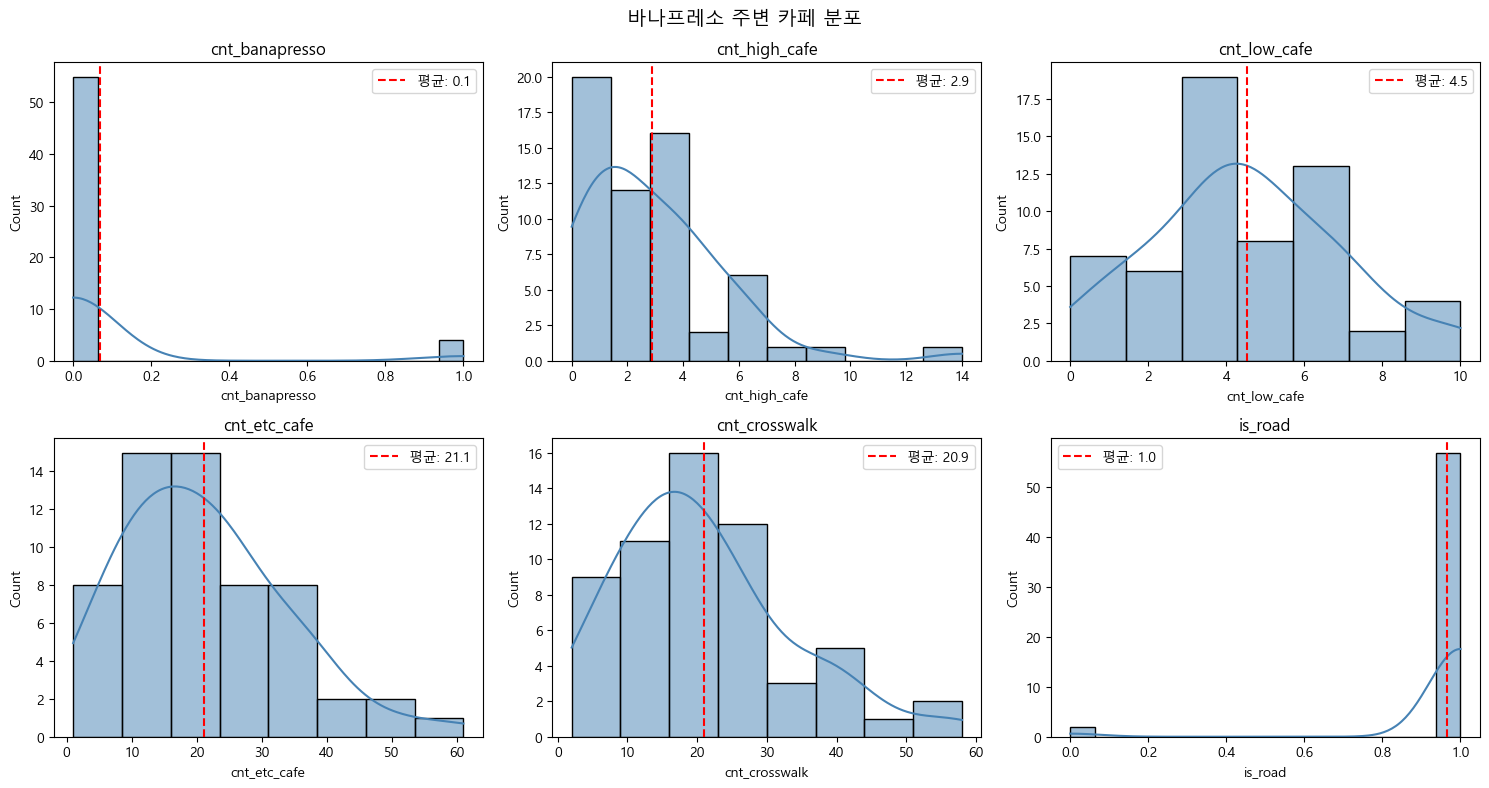

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("바나프레소 주변 카페 분포", fontsize=14)

cols = ["cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe", "cnt_crosswalk", "is_road"]

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(bana_df[col], kde=True, ax=ax, color="steelblue")
    ax.axvline(bana_df[col].mean(), color="red", linestyle="--", label=f"평균: {bana_df[col].mean():.1f}")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

- 고가 카페 (cnt_high_cafe) → 왼쪽 몰림 = 주변에 적은 게 일반적
    - 바나프레소는 고가 카페 없는 곳에 주로 입점
    - 하지만, 비즈니스 적으로 고가 카페가 많은 곳에 저가 카페가 있으면 경쟁력이 분명 있음.
    - 따라서, high better로 유지

- 저가 카페 (cnt_low_cafe) → 종모양, 평균 4.5
    - 딱히 방향성 없음.
    - lower_better 에 추가하기보다는 가중치 낮춤.
- 기타 카페 (cnt_etc_cafe) → 왼쪽 몰림
    - 많다는 것이 상권의 활성화 신호로도 볼 수 있고 아니면, 레드오션으로도 볼 수 있음.
    - 다만, 강남역은 이미 유동인구가 많은 곳. 상권의 활성화 신호는 유동인구로 확인.
    - 따라서, lower_better 로 두되, 가중치는 낮춤.

In [28]:
bana_df.info()

<class 'pandas.DataFrame'>
Index: 59 entries, 0 to 54
Data columns (total 32 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   nm              59 non-null     str           
 1   type            59 non-null     str           
 2   apv_date        59 non-null     datetime64[us]
 3   addr            59 non-null     str           
 4   floor           59 non-null     float64       
 5   sitearea        59 non-null     float64       
 6   lat             59 non-null     float64       
 7   lng             59 non-null     float64       
 8   flpop_type      59 non-null     str           
 9   trdar_cd        55 non-null     float64       
 10  adstrd_cd       59 non-null     int64         
 11  success         59 non-null     int64         
 12  flpop_lunch     59 non-null     float64       
 13  flpop_dinner    59 non-null     float64       
 14  flpop_etc       59 non-null     float64       
 15  cnt_academy     59 non-n

In [44]:
# ── STEP 0. 관심 변수 설정 ──
feature_cols = [
    "flpop_lunch", "flpop_dinner", "flpop_etc",
    "dist_station", "dist_bus_stop",
    "cnt_crosswalk", "is_road",
    "floor_score",
    "cnt_academy", "cnt_hospital", "cnt_school", "cnt_company",
    "cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"
]

# ── STEP 1. 프로파일 가중치 계산 ──
def get_profile_weight(apv_date):
    years = (pd.Timestamp.today() - apv_date).days / 365
    if years >= 3:
        return 3.0
    elif years >= 1:
        return 1.0
    else:
        return 0.5

bana_df["profile_weight"] = bana_df["apv_date"].apply(get_profile_weight)

# ── STEP 1.5 정규화 ──
lower_better = [
    "dist_station", "dist_bus_stop",  # 거리는 가까울수록
    "cnt_banapresso",                  # 자사 경쟁 적을수록
    "cnt_etc_cafe"                     # 기타 카페 적을수록
]
# cnt_low_cafe는 가중치만 낮게 유지 (0.01)

score_df = bana_df[feature_cols].copy()
for col in lower_better:
    score_df[col] = -score_df[col]  # 낮을수록 좋은 건 반전

scaler = MinMaxScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(score_df),
    columns=feature_cols,
    index=bana_df.index
)

# ── STEP 2. 이상적 입지 프로파일 계산 (정규화된 값 기준) ──
ideal_profile = pd.Series({
    col: np.average(scaled[col], weights=bana_df["profile_weight"])
    for col in feature_cols
})

print("이상적 입지 프로파일:")
print(ideal_profile)

이상적 입지 프로파일:
flpop_lunch       0.249383
flpop_dinner      0.234394
flpop_etc         0.274983
dist_station      0.765818
dist_bus_stop     0.722667
cnt_crosswalk     0.335979
is_road           0.970370
floor_score       0.925926
cnt_academy       0.061111
cnt_hospital      0.174074
cnt_school        0.066667
cnt_company       0.067236
cnt_banapresso    0.955556
cnt_high_cafe     0.220635
cnt_low_cafe      0.458519
cnt_etc_cafe      0.640494
dtype: float64


### 프로파일 해석:
- is_road: 0.97 → 대로변 입지 사실상 필수 조건
- floor_score: 0.93 → 1층/저층 선호 매우 강함
- cnt_banapresso: 0.96 → 자사 매장 근처 없는 곳이 일반적 → 중복 출점 지양
- dist_station: 0.77 → 역과 가까운 편
- dist_bus_stop: 0.72 → 버스정류장도 가까운 편
- cnt_crosswalk: 0.34 → 횡단보도는 중간 수준
- cnt_etc_cafe: 0.63 → 기타 카페 어느 정도 있는 곳
- cnt_low_cafe: 0.44 → 저가 카페 경쟁 중간 수준
- cnt_high_cafe: 0.23 → 고가 카페는 적은 곳 선호
- flpop: 0.23~0.27 → 유동인구 중간 이하 (초고밀 상권보다 준상권 선호 가능성)
- cnt_academy/school/company: 0.06~0.07 → 주변 시설 영향 거의 없음

In [45]:
# ── STEP 3. 가중치 설정 ──
weights = {
    # 유동인구 (38%) - 카페 매출 직결, 핵심
    "flpop_lunch":  0.14,
    "flpop_dinner": 0.14,
    "flpop_etc":    0.10,

    # 접근성 (37%) - 프로파일상 가장 일관된 패턴
    "dist_station":  0.08,  # 역 거리
    "dist_bus_stop": 0.07,  # 버스 거리
    "is_road":       0.09,  # 대로변 필수조건
    "cnt_crosswalk": 0.03,  # 보행 접근성
    "floor_score":   0.10,  # 층수 중요 (1층 선호 강함)

    # 주변 시설 (8%) - 프로파일상 거의 없음, 낮게
    "cnt_academy":  0.02,
    "cnt_hospital": 0.02,
    "cnt_school":   0.02,
    "cnt_company":  0.02,

    # 경쟁 강도 (17%) - 자사 경쟁 중심으로
    "cnt_banapresso": 0.08,  # 자사 경쟁 가장 중요
    "cnt_high_cafe":  0.05,  # 상권 소비력 지표
    "cnt_low_cafe":   0.02,  # 방향 불명확
    "cnt_etc_cafe":   0.02,  # 경쟁 신호, 낮게
}

print(sum(weights.values()))  # 1.0 확인

# ── STEP 4. 점수화 ──
def location_score(row, ideal, weights):
    score = 0
    for col in weights:
        if col == "is_road":
            # 1이면 만점, 0이면 0점
            score += (1.0 if row[col] >= 0.5 else 0.0) * weights[col]
        elif col == "cnt_crosswalk":
            # 최소값 2 넘으면 만점
            threshold = 2 / bana_df["cnt_crosswalk"].max()
            score += (1.0 if row[col] >= threshold else row[col] / threshold) * weights[col]
        elif col in ["flpop_lunch", "flpop_dinner", "flpop_etc"]:
            # ideal 이상이면 만점, 미만이면 비례 점수
            score += min(row[col] / ideal_profile[col], 1.0) * weights[col]
        else:
            score += (1 - abs(row[col] - ideal[col])) * weights[col]
    return score

bana_df["location_score"] = scaled.apply(
    lambda row: location_score(row, ideal_profile, weights), axis=1
)

# ── STEP 5. 검증 ──
print(bana_df.groupby("success")["location_score"].mean())
bana_df[["nm", "location_score", "success"]].sort_values("location_score", ascending=False)

1.0
success
0    0.779042
1    0.867612
Name: location_score, dtype: float64


,nm,location_score,success
4,바나프레소 홍대입구역사거리점,0.968424,1
25,바나프레소 서울성균관대점,0.966232,0
5,바나프레소 양재이안점,0.957977,1
50,바나프레소 용산센트럴파크점,0.949220,0
53,바나프레소 동소문점,0.944663,0
0,바나프레소 테헤란로점,0.943451,1
1,바나프레소 신논현역점,0.935490,1
2,바나프레소 선릉공원점,0.932656,1
38,바나프레소 명동중앙우체국점,0.931821,1
41,바나프레소 신림역점,0.927641,0


In [46]:
# success=1 매장 순위 확인
bana_df["rank"] = bana_df["location_score"].rank(ascending=False, method='first').astype(int)
print(bana_df[bana_df["success"]==1][["nm", "location_score", "rank"]].sort_values("rank"))

                 nm  location_score  rank
4   바나프레소 홍대입구역사거리점        0.968424     1
5       바나프레소 양재이안점        0.957977     3
0       바나프레소 테헤란로점        0.943451     6
1       바나프레소 신논현역점        0.935490     7
2       바나프레소 선릉공원점        0.932656     8
38   바나프레소 명동중앙우체국점        0.931821     9
3        바나프레소 충무로점        0.899932    18
24    바나프레소 여의도파크원점        0.794114    35
48       바나프레소 마포역점        0.694357    44
36       바나프레소 양평역점        0.617900    51


In [97]:
print(bana_df.loc[[52, 40], ["nm", "flpop_lunch", "flpop_dinner", "dist_station", "cnt_etc_cafe"]])

            nm  flpop_lunch  flpop_dinner  dist_station  cnt_etc_cafe
52  바나프레소 마포역점    117808.75      141110.0     41.330683            14
40  바나프레소 양평역점     82196.00       68874.0     98.907836            15


# 6. 매물 점수화하기

In [48]:
listing_df = pd.read_csv("C:/vs_code_prj/brewmap/dataAnal/data/listing.csv")
listing_df.head()

,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,maintenance_fee,size_m2,floor,flpop_type,trdar_cd,adstrd_cd
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,0,82.60,4층,T,3120190,11680531
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,0,33.06,1층,T,3120185,11650540
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,0,49.59,2층,T,3120185,11680521
3,455221,서울특별시 강남구 논현동,37.509032,127.023453,한식/고기집,월세,0,220000000,80000000,5500000,1200000,264.50,2층,T,3130303,11680521
4,394623,서울특별시 강남구 논현동,37.515856,127.030844,가구/가전,월세,0,200000000,50000000,3100000,600000,165.00,1층,T,3120191,11680531


In [49]:
listing_df.isna().sum()

listing_id          0
addr                0
lat                 0
lng                 0
business_type       0
transaction_type    0
sale_price          0
key_money           0
deposit             0
monthly_rent        0
maintenance_fee     0
size_m2             0
floor               0
flpop_type          0
trdar_cd            0
adstrd_cd           0
dtype: int64

In [50]:
# 4개 컬럼이 모두 0인 행 제거
mask = (
    (listing_df["key_money"] == 0) &
    (listing_df["deposit"] == 0) &
    (listing_df["monthly_rent"] == 0) &
    (listing_df["maintenance_fee"] == 0)
)

print(f"제거 전: {len(listing_df)}행")
listing_df = listing_df[~mask].reset_index(drop=True)
print(f"제거 후: {len(listing_df)}행")

제거 전: 1319행
제거 후: 1316행


## 6-1. 수요점수 변수 생성

### 유동 인구 수 구하기

In [51]:
# flpop_type T 매핑
tr_mask = listing_df["flpop_type"] == "T"
tr_merged = listing_df[tr_mask].merge(
    flpop_t_agg[["trdar_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="trdar_cd", how="left"
)

# flpop_type A 매핑
ad_mask = listing_df["flpop_type"] == "A"
ad_merged = listing_df[ad_mask].merge(
    flpop_a_agg[["adstrd_cd", "tmzon_11_14_flpop_co", "tmzon_17_21_flpop_co", "flpop_etc"]],
    on="adstrd_cd", how="left"
)

# 합치기 & 컬럼명 정리
listing_df = pd.concat([tr_merged, ad_merged]).sort_index().rename(columns={
    "tmzon_11_14_flpop_co": "flpop_lunch",
    "tmzon_17_21_flpop_co": "flpop_dinner"
})

print(listing_df.shape)
listing_df.head()

(1316, 19)


,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,maintenance_fee,size_m2,floor,flpop_type,trdar_cd,adstrd_cd,flpop_lunch,flpop_dinner,flpop_etc
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,0,82.60,4층,T,3120190,11680531,265091.50,267129.00,233949.2500
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,0,33.06,1층,T,3120185,11650540,388874.50,478718.00,397097.6250
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,0,49.59,2층,T,3120185,11680521,388874.50,478718.00,397097.6250
3,455221,서울특별시 강남구 논현동,37.509032,127.023453,한식/고기집,월세,0,220000000,80000000,5500000,1200000,264.50,2층,T,3130303,11680521,54920.75,80063.75,58347.5000
4,394623,서울특별시 강남구 논현동,37.515856,127.030844,가구/가전,월세,0,200000000,50000000,3100000,600000,165.00,1층,T,3120191,11680531,378147.00,391751.00,381067.3125


### 병원/학교/학원/산업센터 수 구하기

In [52]:
result = listing_df.apply(
    lambda row: count_buildings_nearby(row["lat"], row["lng"], buildings_df),
    axis=1
).fillna(0).astype(int)

listing_df = pd.concat([listing_df, result], axis=1)
listing_df.head()

,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,...,flpop_type,trdar_cd,adstrd_cd,flpop_lunch,flpop_dinner,flpop_etc,cnt_academy,cnt_hospital,cnt_school,cnt_company
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,...,T,3120190,11680531,265091.50,267129.00,233949.2500,0,2,0,0
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,...,T,3120185,11650540,388874.50,478718.00,397097.6250,0,4,0,0
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,...,T,3120185,11680521,388874.50,478718.00,397097.6250,0,4,0,0
3,455221,서울특별시 강남구 논현동,37.509032,127.023453,한식/고기집,월세,0,220000000,80000000,5500000,...,T,3130303,11680521,54920.75,80063.75,58347.5000,0,2,1,0
4,394623,서울특별시 강남구 논현동,37.515856,127.030844,가구/가전,월세,0,200000000,50000000,3100000,...,T,3120191,11680531,378147.00,391751.00,381067.3125,0,1,0,0


## 6-2. 접근성 점수 변수 생성

In [53]:
# listing_df 적용
listing_df["dist_station"]    = listing_df.apply(lambda row: min_distance(row["lat"], row["lng"], station), axis=1)
listing_df["dist_bus_stop"]   = listing_df.apply(lambda row: min_distance(row["lat"], row["lng"], bus_stop), axis=1)
listing_df["cnt_crosswalk"] = listing_df.apply(lambda row: count_within(row["lat"], row["lng"], crosswalk), axis=1)
listing_df["is_road"]     = listing_df.apply(lambda row: is_roadside(row["lat"], row["lng"], road), axis=1)
listing_df

,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,...,flpop_dinner,flpop_etc,cnt_academy,cnt_hospital,cnt_school,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,...,267129.00,233949.2500,0,2,0,0,599.346243,92.458549,17,1
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,...,478718.00,397097.6250,0,4,0,0,117.566068,133.225818,16,1
2,701846,서울특별시 강남구 논현동,37.512658,127.021577,사무실,월세,0,0,35000000,3000000,...,478718.00,397097.6250,0,4,0,0,162.393038,92.381541,16,1
3,455221,서울특별시 강남구 논현동,37.509032,127.023453,한식/고기집,월세,0,220000000,80000000,5500000,...,80063.75,58347.5000,0,2,1,0,288.331569,99.553458,15,1
4,394623,서울특별시 강남구 논현동,37.515856,127.030844,가구/가전,월세,0,200000000,50000000,3100000,...,391751.00,381067.3125,0,1,0,0,191.417015,87.942056,10,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,916785,서울특별시 강남구 역삼동,37.507934,127.038168,기타,매매,140000,0,0,0,...,90985.75,88258.7500,0,0,0,0,346.846302,67.352672,14,1
1312,922447,서울특별시 강남구 논현동,37.505917,127.028315,사무실,월세,0,0,10000000,800000,...,788268.00,560948.1250,0,0,0,0,553.306022,60.186417,2,1
1313,924050,서울특별시 강남구 논현동,37.518160,127.025230,퓨전/쌀국수,월세,0,600000000,100000000,9500000,...,267129.00,233949.2500,0,2,0,0,473.173047,81.982051,6,1
1314,920918,서울특별시 강남구 논현동,37.509918,127.026964,사무실,월세,0,0,20000000,1850000,...,380357.25,434233.7500,0,0,1,0,489.236930,375.838260,1,1


In [54]:
def parse_floor(floor_str):
    if pd.isna(floor_str):
        return 1  # NaN이면 1층으로 처리
    floor_str = str(floor_str)
    if "반지하" in floor_str:
        return -0.5
    if "지하" in floor_str:
        num = re.search(r'\d+', floor_str)
        return -int(num.group()) if num else -1
    num = re.search(r'\d+', floor_str)
    return int(num.group()) if num else 1

# 층수 추출
listing_df["floor"] = listing_df["floor"].apply(parse_floor)

# 층수 점수화 1 점이면 만점, 멀어질수로 0.2 점씩 차감
listing_df["floor_score"] = listing_df["floor"].apply(floor_score)

print(listing_df[["floor", "floor_score"]].drop_duplicates().sort_values("floor"))

      floor  floor_score
454    -4.0          0.0
173    -3.0          0.2
11     -2.0          0.4
5      -1.0          0.6
155    -0.5          0.7
1       1.0          1.0
2       2.0          0.8
6       3.0          0.6
0       4.0          0.4
14      5.0          0.2
27      6.0          0.0
7       7.0          0.0
217     8.0          0.0
566     9.0          0.0
26     10.0          0.0
46     11.0          0.0
110    12.0          0.0
426    13.0          0.0
472    14.0          0.0
1286   15.0          0.0
546    16.0          0.0
1287   17.0          0.0


## 6-3. 경쟁사 비교 점수 변수 생성

In [55]:
# 2)적용 (cafe_idx 파라미터 제거)
result = listing_df.apply(
    lambda row: count_cafes_nearby(row["lat"], row["lng"], cafe),
    axis=1
).fillna(0).astype(int)

listing_df = pd.concat([listing_df, result], axis=1)
# listing_df = pd.concat([listing_df.drop(columns=["cnt_banapresso", "cnt_high_cafe", "cnt_low_cafe", "cnt_etc_cafe"]), result], axis=1)
listing_df.head(2)

,listing_id,addr,lat,lng,business_type,transaction_type,sale_price,key_money,deposit,monthly_rent,...,cnt_company,dist_station,dist_bus_stop,cnt_crosswalk,is_road,floor_score,cnt_banapresso,cnt_high_cafe,cnt_low_cafe,cnt_etc_cafe
0,575115,서울특별시 강남구 논현동,37.519306,127.029262,사무실,월세,0,0,30000000,2000000,...,0,599.346243,92.458549,17,1,0.4,0,1,2,22
1,703777,서울특별시 서초구 잠원동,37.511775,127.020540,카페/커피,월세,0,40000000,50000000,3000000,...,0,117.566068,133.225818,16,1,1.0,0,2,5,35


## 6-4. 비용 리스크 점수 변수 생성

In [ ]:
listing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        1319 non-null   int64  
 1   addr              1319 non-null   str    
 2   lat               1319 non-null   float64
 3   lng               1319 non-null   float64
 4   business_type     1319 non-null   str    
 5   transaction_type  1319 non-null   str    
 6   sale_price        1319 non-null   int64  
 7   key_money         1319 non-null   int64  
 8   deposit           1319 non-null   int64  
 9   monthly_rent      1319 non-null   int64  
 10  maintenance_fee   1319 non-null   int64  
 11  size_m2           1319 non-null   float64
 12  floor             1319 non-null   str    
 13  flpop_type        1319 non-null   str    
 14  trdar_cd          1319 non-null   int64  
 15  adstrd_cd         1319 non-null   int64  
 16  flpop_lunch       1319 non-null   float64
 17  flpop_

In [101]:
listing_df.isna().sum()

listing_id          0
addr                0
lat                 0
lng                 0
business_type       0
transaction_type    0
sale_price          0
key_money           0
deposit             0
monthly_rent        0
maintenance_fee     0
size_m2             0
floor               0
flpop_type          0
trdar_cd            0
adstrd_cd           0
flpop_lunch         0
flpop_dinner        0
flpop_etc           0
cnt_academy         0
cnt_hospital        0
cnt_school          0
cnt_company         0
dist_station        0
dist_bus_stop       0
cnt_crosswalk       0
is_road             0
floor_score         0
cnt_banapresso      0
cnt_high_cafe       0
cnt_low_cafe        0
cnt_etc_cafe        0
dtype: int64

In [56]:
# 사용자 자본금 설정
CAPITAL = 120_000_000  # 1억 2천만원

# ── 1. 실질 월세 계산 ──
listing_df["actual_rent"] = listing_df["monthly_rent"] + listing_df["maintenance_fee"]

# ── 2. 행정동별 평균 실질 월세 계산 ──
dong_avg_rent = listing_df.groupby("adstrd_cd")["actual_rent"].mean()

# ── 3. 비용 리스크 세부 변수 계산 ──

# 1) 월세 지수 (실질 월세 ÷ 행정동 평균 실질 월세)
listing_df["rent_index"] = listing_df.apply(
    lambda row: row["actual_rent"] / dong_avg_rent.get(row["adstrd_cd"], dong_avg_rent.mean()),
    axis=1
)

# 2) 실제 필요 자본금 (창업비용 + 보증금 + 권리금)
listing_df["startup_cost"] = (
    (listing_df["size_m2"] / 33) * 8_370_000
    + listing_df["deposit"]
    + listing_df["key_money"]
)

# 3) 자본금 충당률
listing_df["coverage"] = (CAPITAL / listing_df["startup_cost"]).clip(upper=1.0)

# ── 4. 점수화 ──
# 월세 점수 (10점) - 전체 분포 기준 상대적 저렴함
rent_scaler = MinMaxScaler()
listing_df["rent_score"] = (1 - rent_scaler.fit_transform(
    listing_df[["rent_index"]]
)) * 10

# 자본금 충당 점수 (15점)
listing_df["capital_score"] = listing_df["coverage"] * 15.0

# 비용 리스크 점수 (25점)
listing_df["cost_score"] = listing_df["rent_score"] + listing_df["capital_score"]

# ── 5. 확인 ──
print(listing_df["rent_score"].describe())
print(listing_df["cost_score"].describe())
listing_df[["addr", "actual_rent", "rent_index", "rent_score", "capital_score", "cost_score"]].head()

count    1316.000000
mean        9.439305
std         0.792280
min         0.000000
25%         9.425287
50%         9.652922
75%         9.770115
max        10.000000
Name: rent_score, dtype: float64
count    1316.000000
mean       22.700192
std         3.896806
min         1.533339
25%        22.334906
50%        24.621931
75%        24.762004
max        24.995467
Name: cost_score, dtype: float64


,addr,actual_rent,rent_index,rent_score,capital_score,cost_score
0,서울특별시 강남구 논현동,2000000,0.404274,9.773326,15.000000,24.773326
1,서울특별시 서초구 잠원동,3000000,0.685270,9.615773,15.000000,24.615773
2,서울특별시 강남구 논현동,3000000,0.559091,9.686520,15.000000,24.686520
3,서울특별시 강남구 논현동,6700000,1.248637,9.299896,4.903472,14.203368
4,서울특별시 강남구 논현동,3700000,0.747906,9.580653,6.167552,15.748204


## 6-5. 최종 매물 추천 점수 계산

In [104]:
print([col for col in feature_cols if col not in listing_df.columns])

[]


In [57]:
# ── STEP 1. listing_df 정규화 (bana_df 기준 scaler 재사용) ──
listing_score_df = listing_df[feature_cols].copy()
for col in lower_better:
    listing_score_df[col] = -listing_score_df[col]

listing_scaled = pd.DataFrame(
    scaler.transform(listing_score_df),  # fit은 bana_df 기준, transform만
    columns=feature_cols,
    index=listing_df.index
)

# ── STEP 2. 입지 점수 계산 (0~1) ──
listing_df["location_score"] = listing_scaled.apply(
    lambda row: location_score(row, ideal_profile, weights), axis=1
)

# ── STEP 3. 최종 추천 점수 계산 (0~100) ──
listing_df["recom_score"] = listing_df["location_score"] * 75 + listing_df["cost_score"]

# ── STEP 4. 확인 ──
listing_df[["listing_id", "addr", "location_score", "rent_score", "capital_score", "cost_score", "recom_score"]]\
    .sort_values("recom_score", ascending=False)\
    .head(5)

,listing_id,addr,location_score,rent_score,capital_score,cost_score,recom_score
848,926093,서울특별시 서초구 반포동,0.966870,9.924835,15.0,24.924835,97.440088
144,799151,서울특별시 강남구 신사동,0.957645,9.821503,15.0,24.821503,96.644904
1061,924695,서울특별시 서초구 잠원동,0.958393,9.654195,15.0,24.654195,96.533680
226,857887,서울특별시 강남구 신사동,0.955409,9.603340,15.0,24.603340,96.259040
1054,918954,서울특별시 강남구 신사동,0.951886,9.742171,15.0,24.742171,96.133649


In [58]:
# 최종 순위
listing_df["rank"] = listing_df["recom_score"].rank(ascending=False, method='first').astype(int)

listing_df[["listing_id", "floor", "location_score", "cost_score", "recom_score", "rank"]]\
    .sort_values("rank").head(20)

,listing_id,floor,location_score,cost_score,recom_score,rank
848,926093,1.0,0.966870,24.924835,97.440088,1
144,799151,1.0,0.957645,24.821503,96.644904,2
1061,924695,1.0,0.958393,24.654195,96.533680,3
226,857887,1.0,0.955409,24.603340,96.259040,4
1054,918954,1.0,0.951886,24.742171,96.133649,5
90,499092,1.0,0.948681,24.841328,95.992419,6
329,881607,1.0,0.959730,23.974613,95.954331,7
763,924104,1.0,0.948422,24.807886,95.939526,8
243,808105,1.0,0.949464,24.722324,95.932152,9
327,882189,1.0,0.949464,24.682656,95.892484,10


In [108]:
listing_df.columns

Index(['listing_id', 'addr', 'lat', 'lng', 'business_type', 'transaction_type',
       'sale_price', 'key_money', 'deposit', 'monthly_rent', 'maintenance_fee',
       'size_m2', 'floor', 'flpop_type', 'trdar_cd', 'adstrd_cd',
       'flpop_lunch', 'flpop_dinner', 'flpop_etc', 'cnt_academy',
       'cnt_hospital', 'cnt_school', 'cnt_company', 'dist_station',
       'dist_bus_stop', 'cnt_crosswalk', 'is_road', 'floor_score',
       'cnt_banapresso', 'cnt_high_cafe', 'cnt_low_cafe', 'cnt_etc_cafe',
       'actual_rent', 'rent_index', 'startup_cost', 'coverage', 'rent_score',
       'capital_score', 'cost_score', 'location_score', 'recom_score', 'rank'],
      dtype='str')

# 7. 결과 저장

In [ ]:
listing_df = listing_df.reset_index(drop=True)
listing_df.to_csv("listing_scored_rule.csv", index=False, encoding="utf-8-sig")